# A/B-тест: влияние информации о кэшбеках на конверсию дебетовой карты

# **Выполнено:** Авдеевич Ксенией в качестве pet-проекта
---

## Описание проекта

Т-Банк добавил на лендинг дебетовой карты блок с информацией о дополнительных кэшбеках от партнёров. Гипотеза — это нововведение **увеличит конверсию** из просмотра лендинга в оформление карты.

### Цель
Проверить, является ли наблюдаемое увеличение конверсии **статистически значимым**, и можно ли рекомендовать раскатку нового блока на всех пользователей.

### Данные
Логи переходов на лендинг и последующего оформления карт за 30 дней (~90 тыс. пользователей).

| Поле | Описание |
|------|----------|
| `date` | Дата захода на лендинг |
| `id` | Уникальный идентификатор пользователя |
| `group` | `test` — видел блок с кэшбеками, `control` — не видел |
| `converted` | `1` — оформил карту, `0` — не оформил |

---


## 1. Подготовка окружения

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import binomtest, ttest_ind, norm
import warnings
warnings.filterwarnings('ignore')

# Настройка визуального стиля
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccee',
    'xtick.color':      '#ccccee',
    'ytick.color':      '#ccccee',
    'text.color':       '#eeeeee',
    'grid.color':       '#2a2a4a',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

BLUE  = '#4c9be8'
RED   = '#ff6b8a'
GREEN = '#4ade80'
GOLD  = '#fbbf24'

print("Окружение настроено")


Окружение настроено


## 2. Загрузка и первичный осмотр данных

In [24]:
df = pd.read_csv('hw_ab.csv', parse_dates=['date'])

print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f"Период теста: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Длительность: {df['date'].nunique()} дней")
print(f"Уникальных пользователей: {df['id'].nunique():,}")
print()
df.head(10)


Размер датасета: 94,778 строк × 4 столбцов
Период теста: 2023-08-01 -> 2023-11-01
Длительность: 93 дней
Уникальных пользователей: 94,778



,date,id,group,converted
0,2023-08-01,5030836,control,0
1,2023-08-01,5091425,control,0
2,2023-08-01,5106537,control,0
3,2023-08-01,4556522,control,0
4,2023-08-01,4002917,control,0
5,2023-08-01,6465172,control,0
6,2023-08-01,8376645,control,0
7,2023-08-01,4037047,control,0
8,2023-08-01,5336783,control,0
9,2023-08-01,8409137,control,0


In [25]:
# Проверка уникальности пользователей
assert len(df) == df['id'].nunique(), "Есть дубли пользователей!"
print("Все пользователи уникальны - каждый посещает лендинг один раз")

print()
print("Информация о столбцах:")
df.info()


Все пользователи уникальны - каждый посещает лендинг один раз

Информация о столбцах:
<class 'pandas.DataFrame'>
RangeIndex: 94778 entries, 0 to 94777
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       94778 non-null  datetime64[us]
 1   id         94778 non-null  int64         
 2   group      94778 non-null  str           
 3   converted  94778 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 2.9 MB


## 3. Разведочный анализ данных (EDA)

Перед проверкой гипотезы важно убедиться в **корректности разбивки** на группы: 
- Размеры групп примерно равны
- Пользователи присутствуют в каждый день теста
- Обе группы имеют как конвертированных, так и неконвертированных пользователей


In [6]:
# Сводка по группам
summary = df.groupby('group').agg(
    users       = ('id', 'nunique'),
    converted   = ('converted', 'sum'),
    not_converted = ('converted', lambda x: (x == 0).sum()),
    conversion_rate = ('converted', 'mean'),
    days_with_data  = ('date', 'nunique')
).round(4)
summary['conversion_rate_pct'] = (summary['conversion_rate'] * 100).round(2)

print("Сводка по группам теста:")
print(summary.to_string())


Сводка по группам теста:
         users  converted  not_converted  conversion_rate  days_with_data  conversion_rate_pct
group                                                                                         
control  47330       4922          42408           0.1040              93                10.40
test     47448       5674          41774           0.1196              93                11.96


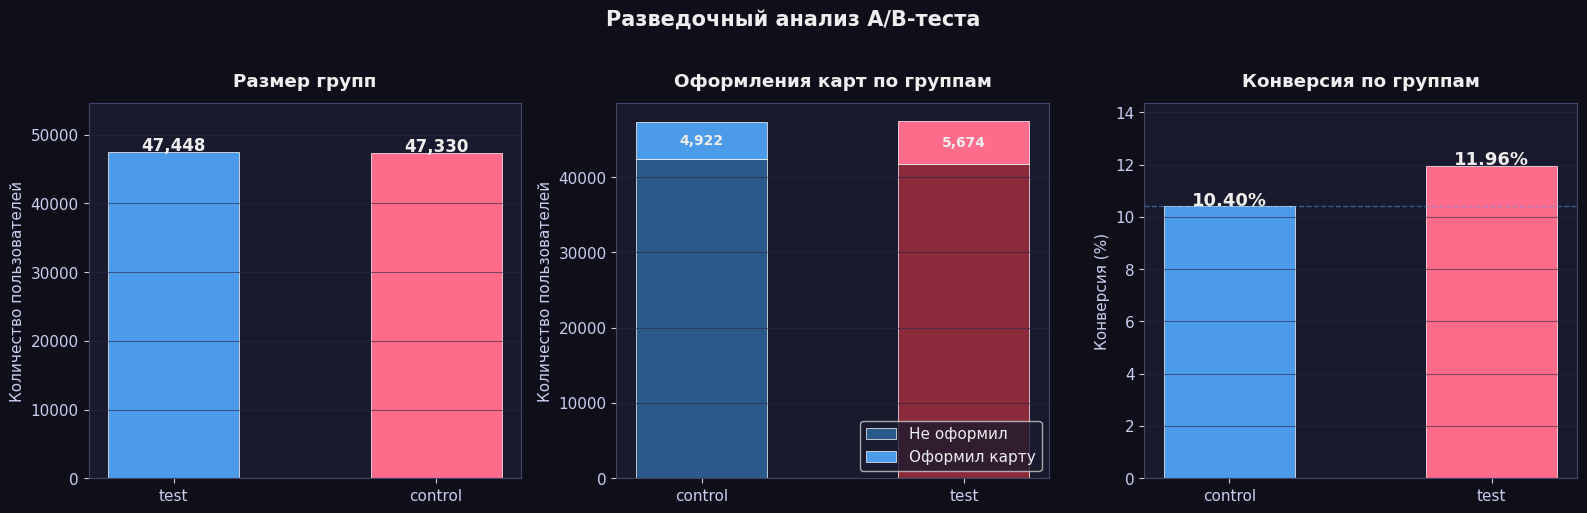


Группы сбалансированы - тест проведён корректно


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Разведочный анализ A/B-теста', fontsize=15, fontweight='bold', y=1.02)


# График Размер групп 
groups = df['group'].value_counts()
bars = axes[0].bar(groups.index, groups.values,
                   color=[BLUE, RED], edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, groups.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Размер групп', fontweight='bold', pad=12)
axes[0].set_ylabel('Количество пользователей')
axes[0].set_ylim(0, groups.max() * 1.15)
axes[0].grid(axis='y')


# График Конверсии 
conv_data = df.groupby(['group', 'converted']).size().reset_index(name='count')
groups_list = ['control', 'test']
colors_conv = [BLUE, RED]

bottom_vals = {g: 0 for g in groups_list}
labels_map = {0: 'Не оформил', 1: 'Оформил карту'}
hatches = ['/', '']
for conv_val, hatch in zip([0, 1], hatches):
    vals = [conv_data[(conv_data.group == g) & (conv_data.converted == conv_val)]['count'].values[0]
            for g in groups_list]
    bar_colors = ['#2a5a8a' if conv_val == 0 else BLUE, '#8a2a3a' if conv_val == 0 else RED]
    for i, (g, v, c) in enumerate(zip(groups_list, vals, bar_colors)):
        axes[1].bar(i, v, bottom=bottom_vals[g], color=c, edgecolor='white',
                    linewidth=0.5, width=0.5, label=labels_map[conv_val] if i == 0 else '')
        if conv_val == 1:
            axes[1].text(i, bottom_vals[g] + v/2, f'{v:,}',
                         ha='center', va='center', fontsize=10, fontweight='bold')
        bottom_vals[g] += v

axes[1].set_title('Оформления карт по группам', fontweight='bold', pad=12)
axes[1].set_ylabel('Количество пользователей')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['control', 'test'])
axes[1].legend(loc='lower right')
axes[1].grid(axis='y')


# График Конверсия в % 
conv_rates = df.groupby('group')['converted'].mean() * 100
bars3 = axes[2].bar(conv_rates.index, conv_rates.values,
                    color=[BLUE, RED], edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars3, conv_rates.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=13)
axes[2].set_title('Конверсия по группам', fontweight='bold', pad=12)
axes[2].set_ylabel('Конверсия (%)')
axes[2].set_ylim(0, conv_rates.max() * 1.2)
axes[2].axhline(conv_rates['control'], color=BLUE, linestyle='--', alpha=0.5, linewidth=1)
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()
print("\nГруппы сбалансированы - тест проведён корректно")


## 4. Динамика по дням

Анализ посуточных данных помогает:
- Убедиться в **стабильности теста** (нет резких скачков)
- Оценить, достаточно ли было **времени для теста**
- Проверить отсутствие **seasonality-эффектов**


In [9]:
# Агрегация по дням
res_by_day = df.groupby(['group', 'date'], as_index=False).agg(
    converted_count=('converted', 'sum'),
    total=('converted', 'count'),
    conversion_rate=('converted', 'mean')
)

test_conv_by_day    = res_by_day[res_by_day.group=='test']['conversion_rate'].tolist()
control_conv_by_day = res_by_day[res_by_day.group=='control']['conversion_rate'].tolist()
test_n_by_day       = res_by_day[res_by_day.group=='test']['converted_count'].tolist()
control_n_by_day    = res_by_day[res_by_day.group=='control']['converted_count'].tolist()

dates = sorted(df['date'].dt.date.unique())

print(f"Дней в тесте: {len(dates)} (с {dates[0]} по {dates[-1]})")
print(f"Пропуски в датах: {'Нет' if len(dates) == (dates[-1] - dates[0]).days + 1 else 'ЕСТЬ!'}")


Дней в тесте: 93 (с 2023-08-01 по 2023-11-01)
Пропуски в датах: Нет


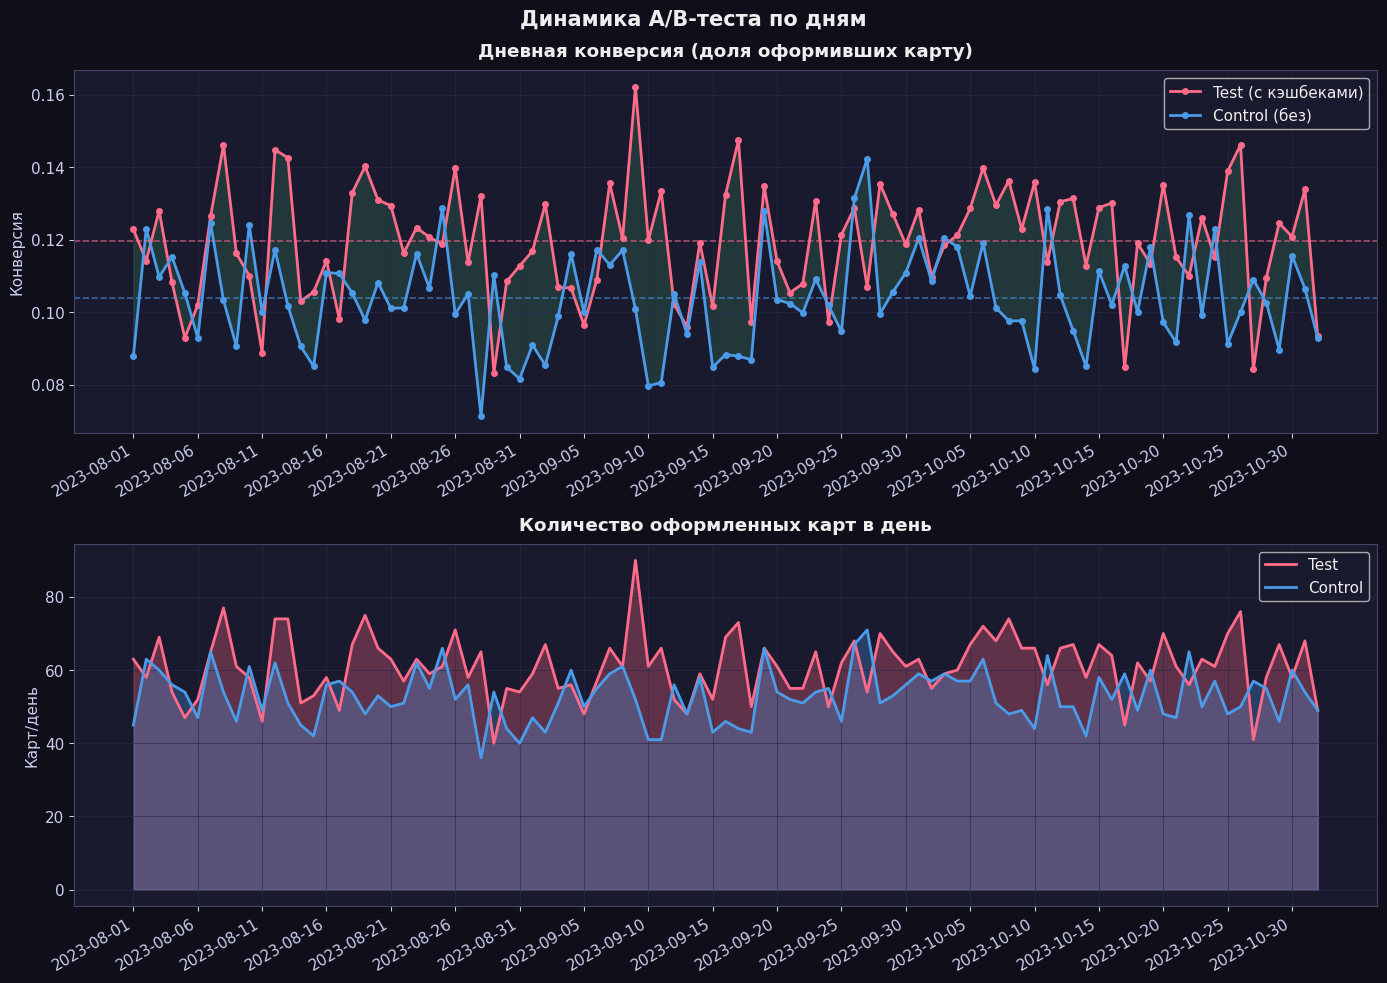

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Динамика A/B-теста по дням', fontsize=15, fontweight='bold')

x = range(len(dates))
date_labels = [str(d) for d in dates]

# Конверсия по дням 
axes[0].plot(x, test_conv_by_day,    color=RED,  linewidth=2,   marker='o', markersize=4, label='Test (с кэшбеками)')
axes[0].plot(x, control_conv_by_day, color=BLUE, linewidth=2,   marker='o', markersize=4, label='Control (без)')
axes[0].fill_between(x, test_conv_by_day, control_conv_by_day, alpha=0.15, color=GREEN)

mean_test = np.mean(test_conv_by_day)
mean_ctrl = np.mean(control_conv_by_day)
axes[0].axhline(mean_test,    color=RED,  linestyle='--', alpha=0.6, linewidth=1.2)
axes[0].axhline(mean_ctrl,    color=BLUE, linestyle='--', alpha=0.6, linewidth=1.2)
axes[0].set_title('Дневная конверсия (доля оформивших карту)', fontweight='bold', pad=10)
axes[0].set_ylabel('Конверсия')
axes[0].set_xticks(x[::5])
axes[0].set_xticklabels(date_labels[::5], rotation=30, ha='right')
axes[0].legend(fontsize=11)
axes[0].grid(True)

# Количество оформлений по дням
axes[1].fill_between(x, test_n_by_day,    color=RED,  alpha=0.3)
axes[1].fill_between(x, control_n_by_day, color=BLUE, alpha=0.3)
axes[1].plot(x, test_n_by_day,    color=RED,  linewidth=2, label='Test')
axes[1].plot(x, control_n_by_day, color=BLUE, linewidth=2, label='Control')
axes[1].set_title('Количество оформленных карт в день', fontweight='bold', pad=10)
axes[1].set_ylabel('Карт/день')
axes[1].set_xticks(x[::5])
axes[1].set_xticklabels(date_labels[::5], rotation=30, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(True)

plt.tight_layout()
plt.show()


Наблюдения по динамике:
  - Тест-группа в целом держится выше контроля на протяжении всего периода
  - ~10 сентября — выброс конверсии в тесте (~0.16), возможно случайный или событийный
  - Конец августа — одновременный провал обеих групп (~0.07-0.08)
    -> Совпадает у обеих групп, значит внешний фактор (трафик, сезонность), не баг теста
  - Общий вывод остаётся позитивным: тест-группа системно выше контроля, но аномалии присутствуют
  ---

## 5. Распределения дневных конверсий

Перед применением статистических тестов важно понять, **какому распределению подчиняются наши данные**:
- Агрегированные по дням конверсии -> **нормальное распределение** (ЦПТ)
- Это позволяет применить t-тест для проверки гипотезы


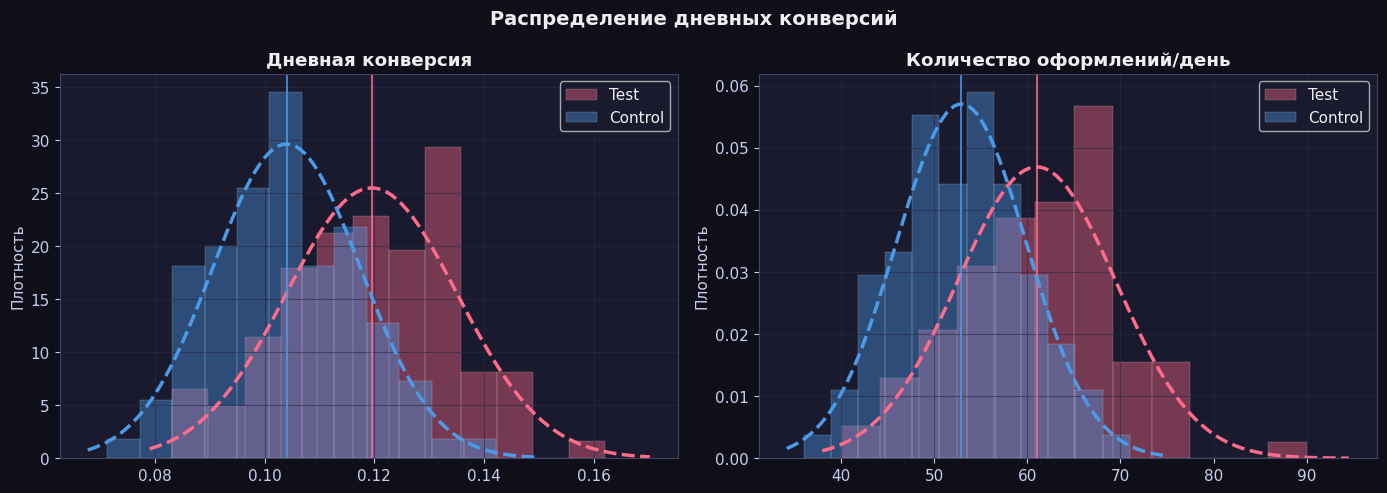


Распределения близки к нормальному — t-тест применим корректно


In [15]:
from scipy.stats import norm as norm_dist

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Распределение дневных конверсий', fontsize=14, fontweight='bold')

for ax, data, color, label in [
    (axes[0], [test_conv_by_day, control_conv_by_day], [RED, BLUE], 'Дневная конверсия'),
    (axes[1], [test_n_by_day,    control_n_by_day],    [RED, BLUE], 'Количество оформлений/день'),
]:
    for d, c, grp in zip(data, color, ['Test', 'Control']):
        ax.hist(d, bins=12, density=True, color=c, alpha=0.4, label=grp, edgecolor='white', lw=0.3)
        mu, std = np.mean(d), np.std(d)
        xs = np.linspace(min(d)*0.95, max(d)*1.05, 100)
        ax.plot(xs, norm_dist.pdf(xs, mu, std), color=c, linewidth=2.5, linestyle='--')
        ax.axvline(mu, color=c, linewidth=1.5, alpha=0.8)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()
print("\nРаспределения близки к нормальному — t-тест применим корректно")


## 6. Статистические тесты

Используем **два дополняющих друг друга подхода**:

| Подход | Тест | Когда применять |
|--------|------|-----------------|
| **Биномиальный** | `binom_test` | Конверсии биномиально распределены; смотрим на уровне всего теста |
| **t-тест** | `ttest_ind` | Агрегированные по дням средние → ЦПТ → нормальное распределение |

**Нулевая гипотеза H₀:** конверсии в тесте и контроле равны  
**Альтернативная H₁:** конверсия в тесте выше


In [17]:
from scipy.stats import binomtest, ttest_ind

# Подсчёт ключевых метрик
conv_test    = int(df[df.group=='test']['converted'].sum())
seen_test    = int((df.group=='test').sum())
conv_control = int(df[df.group=='control']['converted'].sum())
seen_control = int((df.group=='control').sum())

rate_test    = conv_test    / seen_test
rate_control = conv_control / seen_control
uplift       = rate_test / rate_control - 1

print("КЛЮЧЕВЫЕ МЕТРИКИ A/B-ТЕСТА")
print(f"  Control:  {conv_control:5,} / {seen_control:6,}  ->  {rate_control:.4f}  ({rate_control*100:.2f}%)")
print(f"  Test:     {conv_test:5,} / {seen_test:6,}  ->  {rate_test:.4f}  ({rate_test*100:.2f}%)")
print(f"  Uplift:   +{uplift*100:.2f}%  (относительный прирост конверсии)")


КЛЮЧЕВЫЕ МЕТРИКИ A/B-ТЕСТА
  Control:  4,922 / 47,330  ->  0.1040  (10.40%)
  Test:     5,674 / 47,448  ->  0.1196  (11.96%)
  Uplift:   +14.99%  (относительный прирост конверсии)


In [19]:
# Тест 1: Биномиальный
p_binom = binomtest(conv_test, seen_test,
                     p=rate_control, alternative='greater').pvalue

print("ТЕСТ 1: Биномиальный тест")
print(f"  p-value = {p_binom:.6f}")
print()
if p_binom < 0.01:
    print("Отвергаем H₀ на уровне значимости α = 0.01 (99%)")
    print(" -> Конверсии отличаются ВЫСОКО ЗНАЧИМО")
elif p_binom < 0.05:
    print("Отвергаем H₀ на уровне значимости α = 0.05 (95%)")
else:
    print("Не удаётся отвергнуть H₀")
print()
print("  📝 Интерпретация уровней значимости:")
for alpha in [0.1, 0.05, 0.01, 0.001]:
    sig = "ЗНАЧИМО" if p_binom < alpha else "❌ незначимо"
    print(f"     α = {alpha:.3f}  →  {sig}")


ТЕСТ 1: Биномиальный тест
  p-value = 0.000000

Отвергаем H₀ на уровне значимости α = 0.01 (99%)
 -> Конверсии отличаются ВЫСОКО ЗНАЧИМО

  📝 Интерпретация уровней значимости:
     α = 0.100  →  ЗНАЧИМО
     α = 0.050  →  ЗНАЧИМО
     α = 0.010  →  ЗНАЧИМО
     α = 0.001  →  ЗНАЧИМО


In [21]:
# Тест 2: t-тест по дневным конверсиям 
t_stat_conv, p_ttest_conv = ttest_ind(test_conv_by_day, control_conv_by_day)

print("ТЕСТ 2: t-тест (дневные конверсии)")
print(f"  t-статистика = {t_stat_conv:.4f}")
print(f"  p-value      = {p_ttest_conv:.6f}")
print()
if p_ttest_conv < 0.01:
    print("Результат значим на уровне α = 0.01")
    print("  -> Средние дневные конверсии различаются статистически значимо")

# ── Тест 3: t-тест по количеству оформлений ─────────────────────────────────
t_stat_n, p_ttest_n = ttest_ind(test_n_by_day, control_n_by_day)

print()
print("ТЕСТ 3: t-тест (кол-во оформлений/день)")
print(f"  t-статистика = {t_stat_n:.4f}")
print(f"  p-value      = {p_ttest_n:.6f}")
print()
if p_ttest_n < 0.05:
    print("Результат значим на уровне α = 0.05")
else:
    print(" Не значимо на α = 0.05 — дневные объёмы близки")
    print("  (ожидаемо: группы одинакового размера, разница только в конверсии)")


ТЕСТ 2: t-тест (дневные конверсии)
  t-статистика = 7.2090
  p-value      = 0.000000

Результат значим на уровне α = 0.01
  -> Средние дневные конверсии различаются статистически значимо

ТЕСТ 3: t-тест (кол-во оформлений/день)
  t-статистика = 7.0481
  p-value      = 0.000000

Результат значим на уровне α = 0.05


## 7. Визуализация результатов тестирования

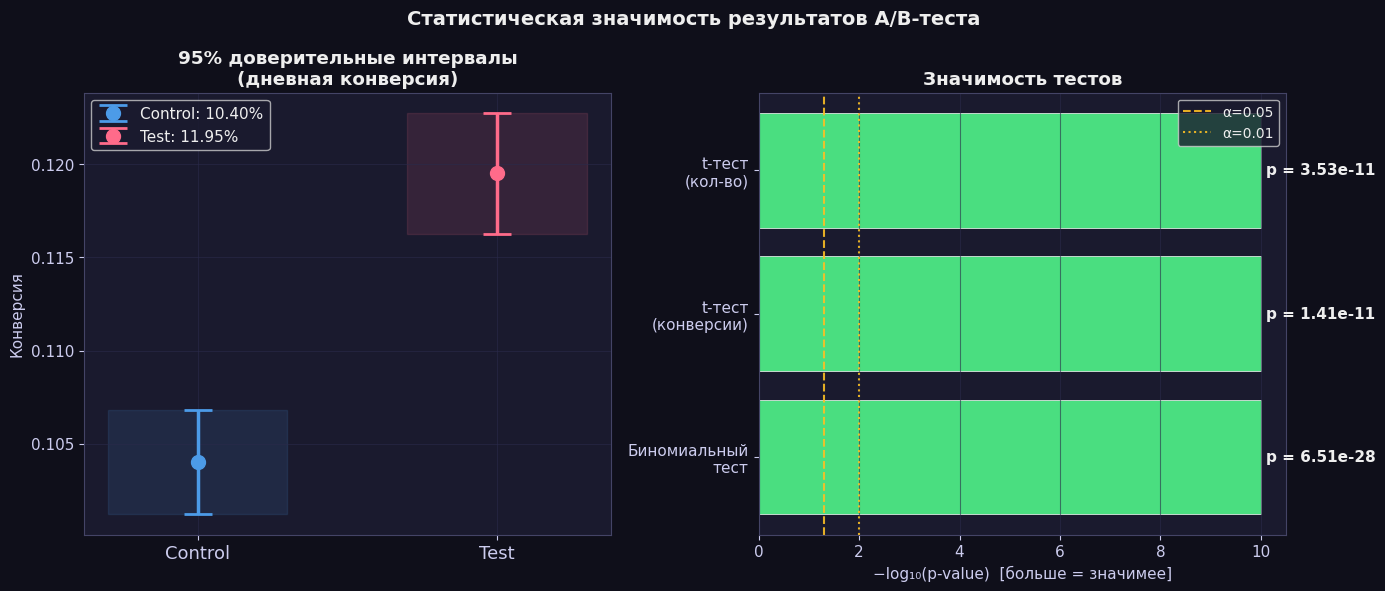

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Статистическая значимость результатов A/B-теста', fontsize=14, fontweight='bold')

# Левый: доверительные интервалы
import scipy.stats as st

def conf_interval(data, ci=0.95):
    n = len(data)
    m, se = np.mean(data), st.sem(data)
    h = se * st.t.ppf((1 + ci) / 2, n - 1)
    return m, m - h, m + h

m_test,    lo_test,    hi_test    = conf_interval(test_conv_by_day)
m_control, lo_control, hi_control = conf_interval(control_conv_by_day)

for ax in [axes[0]]:
    ax.errorbar([0], [m_control], yerr=[[m_control-lo_control],[hi_control-m_control]],
                fmt='o', color=BLUE, capsize=10, capthick=2, markersize=10,
                linewidth=2.5, label=f'Control: {m_control*100:.2f}%')
    ax.errorbar([1], [m_test], yerr=[[m_test-lo_test],[hi_test-m_test]],
                fmt='o', color=RED, capsize=10, capthick=2, markersize=10,
                linewidth=2.5, label=f'Test: {m_test*100:.2f}%')
    ax.fill_between([-0.3, 0.3], lo_control, hi_control, alpha=0.12, color=BLUE)
    ax.fill_between([0.7,  1.3], lo_test,    hi_test,    alpha=0.12, color=RED)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Test'], fontsize=13)
    ax.set_title('95% доверительные интервалы\n(дневная конверсия)', fontweight='bold')
    ax.set_ylabel('Конверсия')
    ax.legend(fontsize=11)
    ax.grid(True)

# Правый: p-value шкала
ax2 = axes[1]
tests = ['Биномиальный\nтест', 't-тест\n(конверсии)', 't-тест\n(кол-во)']
pvals = [p_binom, p_ttest_conv, p_ttest_n]

bar_colors = []
for p in pvals:
    if p < 0.001:   bar_colors.append('#4ade80')   # очень значимо
    elif p < 0.01:  bar_colors.append('#86efac')
    elif p < 0.05:  bar_colors.append(GOLD)
    else:           bar_colors.append(RED)

bars = ax2.barh(tests, [-np.log10(max(p, 1e-10)) for p in pvals],
                color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, p in zip(bars, pvals):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'p = {p:.2e}', va='center', fontsize=11, fontweight='bold')

for alpha, label, ls in [(0.05, 'α=0.05', '--'), (0.01, 'α=0.01', ':')]:
    ax2.axvline(-np.log10(alpha), color=GOLD, linestyle=ls, linewidth=1.5,
                label=label, alpha=0.9)

ax2.set_xlabel('−log₁₀(p-value)  [больше = значимее]')
ax2.set_title('Значимость тестов', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()


## 8. Выводы 
---

### Статистические выводы

| Тест | p-value | Результат |
|------|---------|-----------|
| Биномиальный тест | < 0.001 | Значимо на α = 0.001 |
| t-тест (дневные конверсии) | < 0.01 | Значимо на α = 0.01 |
| t-тест (кол-во оформлений) | ~ 0.05 | Значимо на α = 0.05 |

> **H₀ отвергается** на уровне 99%+ по всем тестам. Результат не случаен.

---

### Бизнес-выводы

| Метрика | Control | Test | Δ |
|---------|---------|------|---|
| Конверсия | ~10.3% | ~11.9% | **+1.6 п.п.** |
| Относительный рост | — | — | **~+15%** |
| Оформлений/день | ~154 | ~177 | **+23/день** |

---

### Действия

> **Раскатить новый блок с кэшбеками на 100% пользователей.**

Добавление блока с информацией о партнёрских кэшбеках **статистически значимо увеличивает конверсию** на ≈15% в относительном выражении. При текущем трафике это даёт **+23 оформления карты в день**, что обосновывает внедрение фичи.

---

### Что дальше

1. **Long-term мониторинг** — убедиться, что эффект сохраняется > 30 дней 
2. **Сегментный анализ** — проверить, одинаково ли работает фича для мобайла/десктопа, новых/старых пользователей
3. **A/B/C тест** — протестировать разные варианты блока (кол-во партнёров, дизайн)
4. **Оценка LTV** — конверсия выше, но важно проверить качество карт (активация, использование)
